# ExoLinker: Full Planetary Profile Generation
This notebook demonstrates how to couple an `exowrap` atmosphere model with a `fuzzycore` interior model to generate a continuous, mathematically rigorous planetary profile.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import our newly built exolinker package!
from exolinker import ExoCoupler, save_converged_model

# Set matplotlib style for nice scientific plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

In [2]:
# 1. Define the physical parameters for our target planet
target_params = {
    "mass": 1.0,               # Jupiter masses
    "T_irr": 1000.0,           # Irradiation temperature (K)
    "Met": 0.0,                # Metallicity (log10 Z/Z_solar)
    "core_mass_earth": 15.0,   # Solid core mass in Earth masses
    "iron_fraction": 0.33,     # Earth-like core composition
    "f_sed": 1.0,              # Cloud sedimentation
    "kzz": 8.0,                 # Eddy diffusion (log10)
    "debug": True
    # Note: We omit 'T_int' and 'g_1bar' so the coupler uses its smart initialization!
}

# 2. Define the numerical configuration for the solver
config = {
    "resolution": 50,                  # exowrap K-table resolution
    "max_iterations": 15,              # Maximum Secant method steps
    "p_link_target_bar": 100.0,        # Where to stitch the models
    "mass_convergence_threshold": 0.01,# 1% mass tolerance
    "t_int_convergence_threshold": 0.01# 1% T_int tolerance
}

In [3]:
# 3. Initialize the Orchestrator
coupler = ExoCoupler(target_params=target_params, config=config)

# 4. Fire the main solver loop! (This will take a few minutes)
print("🚀 Launching ExoLinker...")
results = coupler.run()

if results['status'] == 'converged':
    print(f"\n✅ Success! Converged in {results['iterations']} iterations.")
    print(f"Final T_int: {results['final_params']['T_int']:.1f} K")
    print(f"Final g_1bar: {results['final_params']['g_1bar']:.2f} m/s²")
else:
    print("\n❌ Solver failed to converge. Check the history for details.")


if results['status'] == 'failed':
    # Now this will successfully grab the DataFrame!
    raw_atm = results['atmosphere_raw']
    print("\n--- Failed Run Diagnostics ---")
    
    # Expose the ExoremOut properties
    from exowrap.output import ExoremOut
    exo = ExoremOut(raw_atm)
    
    print(f"Atmosphere T_int used: {exo.t_int:.1f} K")
    print(f"Atmosphere Gravity used: {exo.gravity[-1]:.2f} m/s²")
    
    # Find the boundary conditions it tried to pass to fuzzycore
    p_levels_bar = exo.pressure_levels / 1e5
    t_levels = exo.temperature_levels
    
    # Let's see what the temperature is at 100 bar!
    idx_link = np.argmin(np.abs(p_levels_bar - config['p_link_target_bar']))
    
    print(f"Deepest Exorem Boundary: P = {p_levels_bar[idx_link]:.2f} bar, T = {t_levels[idx_link]:.1f} K")


INFO: 💡 Smart Initialization: Guessed g = 24.78 m/s² for M = 1.0 M_Jup
INFO: 
INFO: 🔄 ITERATION 1/15 | T_int: 500.0 K | g: 24.78 m/s²
INFO: ========================================
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpa_1jgv4k/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


🚀 Launching ExoLinker...


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpa_1jgv4k/outputs/exowrap_run.h5...
INFO: Simulation complete.


--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
[START] Pc=1.00e+12 -> P_int=1.00e+12 -> T_int=630957.3 K
[SUCCESS] M=101.530 Mj
[START] Pc=1.00e+13 -> P_int=1.00e+13 -> T_int=630957.3 K
[SUCCESS] M=220.707 Mj
[START] Pc=3.16e+11 -> P_int=3.16e+11 -> T_int=630957.3 K
[SUCCESS] M=66.880 Mj
[START] Pc=1.00e+12 -> P_int=1.00e+12 -> T_int=630957.3 K
[SUCCESS] M=101.530 Mj
[START] Pc=1.00e+11 -> P_int=1.00e+11 -> T_int=630957.3 K
[SUCCESS] M=44.133 Mj
[START] Pc=3.16e+11 -> P_int=3.16e+11 -> T_int=630957.3 K
[SUCCESS] M=66.880 Mj
[START] Pc=3.16e+10 -> P_int=3.16e+10 -> T_int=630844.4 K
[SUCCESS] M=29.075 Mj
[START] Pc=1.00e+11 -> P_int=1.00e+11

INFO: Calculated T_int: 544.97 K (Avg Deep Flux = 5.001e+03 W/m²)
INFO: 📊 Results: Calc Mass = 1.570 M_Jup (Error: 56.97%)
INFO: 📊 Results: T_int = 545.0 K (Error: 8.99%)
INFO: 📈 Secant Prep: Nudging gravity to establish mass gradient.
INFO: 
INFO: 🔄 ITERATION 2/15 | T_int: 513.5 K | g: 26.02 m/s²
INFO: ========================================
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp5u2tgjlw/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


...

[SUCCESS] M=1.022 Mj


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp_9c88dee/outputs/exowrap_run.h5...
INFO: Simulation complete.


[START] Pc=1.00e+12 -> P_int=1.00e+12 -> T_int=630957.3 K
[SUCCESS] M=103.378 Mj
[START] Pc=1.00e+13 -> P_int=1.00e+13 -> T_int=630957.3 K
[SUCCESS] M=220.893 Mj
[START] Pc=3.16e+11 -> P_int=3.16e+11 -> T_int=630957.3 K
[SUCCESS] M=68.459 Mj
[START] Pc=1.00e+12 -> P_int=1.00e+12 -> T_int=630957.3 K
[SUCCESS] M=103.378 Mj
[START] Pc=1.00e+11 -> P_int=1.00e+11 -> T_int=630957.3 K
[SUCCESS] M=45.176 Mj
[START] Pc=3.16e+11 -> P_int=3.16e+11 -> T_int=630957.3 K
[SUCCESS] M=68.459 Mj
[START] Pc=3.16e+10 -> P_int=3.16e+10 -> T_int=630957.3 K
[SUCCESS] M=29.773 Mj
[START] Pc=1.00e+11 -> P_int=1.00e+11 -> T_int=630957.3 K
[SUCCESS] M=45.176 Mj
[START] Pc=1.00e+10 -> P_int=9.97e+09 -> T_int=442652.8 K
[SUCCESS] M=19.510 Mj
[START] Pc=3.16e+10 -> P_int=3.16e+10 -> T_int=630957.3 K
[SUCCESS] M=29.773 Mj
[START] Pc=3.16e+09 -> P_int=3.13e+09 -> T_int=295787.5 K
[SUCCESS] M=12.541 Mj
[START] Pc=1.00e+10 -> P_int=9.97e+09 -> T_int=442652.8 K
[SUCCESS] M=19.510 Mj
[START] Pc=1.00e+09 -> P_int=8.09e+08

INFO: 📊 Results: Calc Mass = 0.995 M_Jup (Error: -0.46%)
INFO: 📊 Results: T_int = 517.9 K (Error: 0.00%)
INFO: ✅ CONVERGED in 5 iterations!
INFO: Stitching profiles at P_link = 100.00 bar


[SUCCESS] M=0.995 Mj

✅ Success! Converged in 5 iterations.
Final T_int: 517.9 K
Final g_1bar: 14.68 m/s²


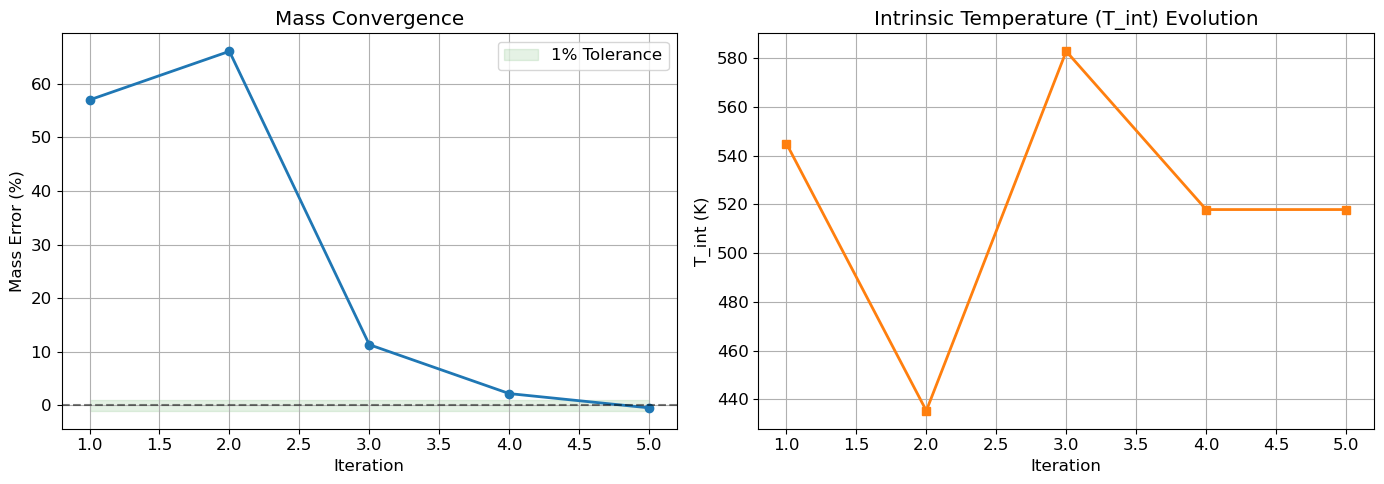

In [8]:
# 5. Visualize the Secant Method at work
history = coupler.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gravity Error Plot
ax1.plot(history['iteration'], np.array(history['mass_error']) * 100, marker='o', color='tab:blue', lw=2)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.fill_between(history['iteration'], -1, 1, color='green', alpha=0.1, label="1% Tolerance")
ax1.set_title("Mass Convergence")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Mass Error (%)")
ax1.legend()

# T_int Plot
ax2.plot(history['iteration'], history['T_int'], marker='s', color='tab:orange', lw=2)
ax2.set_title("Intrinsic Temperature (T_int) Evolution")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("T_int (K)")

plt.tight_layout()
plt.show()

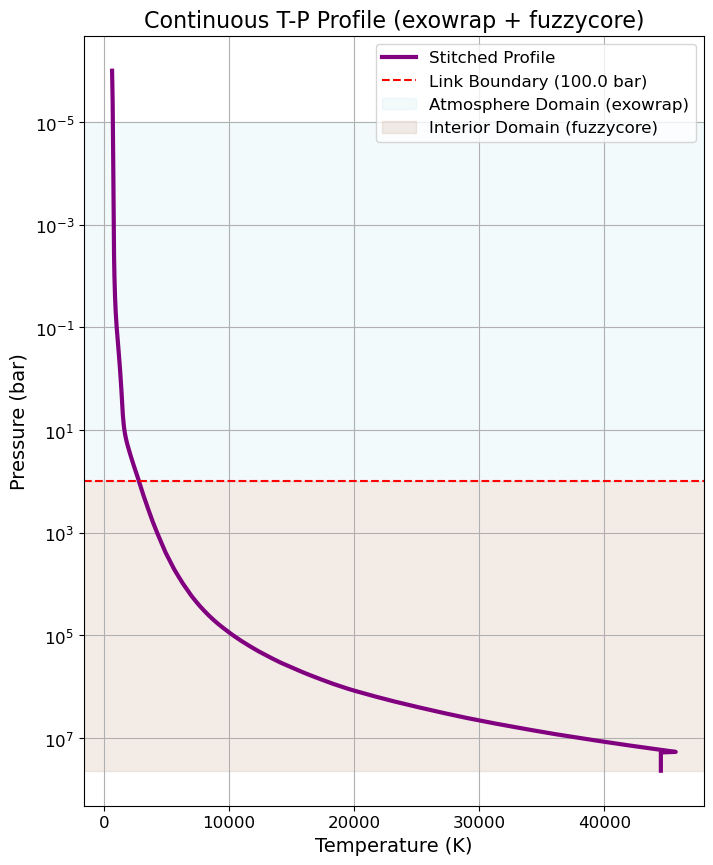

In [9]:
# 6. Visualize the continuous planetary profile
if results['status'] == 'converged':
    df = results['stitched_profile']
    p_link = config['p_link_target_bar']
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # Plot the full profile
    ax.plot(df['Temperature_K'], df['Pressure_bar'], color='purple', lw=3, label='Stitched Profile')
    
    # Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', label=f'Link Boundary ({p_link} bar)')
    
    # Format the axes for atmospheric science standards (log pressure, inverted)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Continuous T-P Profile (exowrap + fuzzycore)", fontsize=16)
    
    # Fill background colors to show domains
    ax.axhspan(1e-5, p_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior Domain (fuzzycore)')
    
    ax.legend(loc='upper right')
    plt.show()

In [11]:
# 7. Save the data securely to disk using our new io.py module
if results['status'] == 'converged':
    saved_path = save_converged_model(results, output_dir="../exolinker_outputs")
    print(f"Data saved to: {saved_path}")
    
    # You can easily read it back later!
    # import pickle
    # with open(saved_path, 'rb') as f:
    #     data = pickle.load(f)
    # display(data['profile'].head())

INFO: 💾 Converged model saved successfully to: ../exolinker_outputs/results/M_1.00_Tint_517.9_Met_0.00.pkl


Data saved to: ../exolinker_outputs/results/M_1.00_Tint_517.9_Met_0.00.pkl
